In [1]:
import pandas as pd
df=pd.read_csv("diabetes_dataset.csv")
df.head()

,Unnamed: 0,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,...,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes,Previous_Gestational_Diabetes
0,0,58,Female,White,35.8,83.4,123.9,10.9,152,114,...,50.2,99.2,37.5,7.2,Moderate,1538,Moderate,Never,0,1
1,1,48,Male,Asian,24.1,71.4,183.7,12.8,103,91,...,62.0,146.4,88.5,6.1,Moderate,2653,Moderate,Current,0,1
2,2,34,Female,Black,25.0,113.8,142.0,14.5,179,104,...,32.1,164.1,56.2,6.9,Low,1684,Heavy,Former,1,0
3,3,62,Male,Asian,32.7,100.4,167.4,8.8,176,118,...,41.1,84.0,34.4,5.4,Low,3796,Moderate,Never,1,0
4,4,27,Female,Asian,33.5,110.8,146.4,7.1,122,97,...,53.9,92.8,81.9,7.4,Moderate,3161,Heavy,Current,0,0


In [2]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Ethnicity', 'BMI', 'Waist_Circumference',
       'Fasting_Blood_Glucose', 'HbA1c', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Cholesterol_Total', 'Cholesterol_HDL',
       'Cholesterol_LDL', 'GGT', 'Serum_Urate', 'Physical_Activity_Level',
       'Dietary_Intake_Calories', 'Alcohol_Consumption', 'Smoking_Status',
       'Family_History_of_Diabetes', 'Previous_Gestational_Diabetes'],
      dtype='str')

In [3]:
df["Risk_Score"] = (
    df["HbA1c"]*0.35 +
    df["Fasting_Blood_Glucose"]*0.30 +
    df["BMI"]*0.15 +
    df["Age"]*0.10 +
    df["Waist_Circumference"]*0.10
)

df["Diabetes_Risk"] = pd.qcut(
    df["Risk_Score"],
    q=3,
    labels=[0,1,2]
)

In [4]:
features = [
"Age",
"BMI",
"Waist_Circumference",
"Fasting_Blood_Glucose",
"HbA1c",
"Blood_Pressure_Systolic",
"Blood_Pressure_Diastolic",
"Cholesterol_HDL",
"Cholesterol_LDL",
"GGT",
"Serum_Urate",
"Family_History_of_Diabetes",
"Physical_Activity_Level",
"Smoking_Status"
]


X = df[features]

y = df["Diabetes_Risk"]

In [5]:
df["Diabetes_Risk"].value_counts()

Diabetes_Risk
0    3334
1    3334
2    3332
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


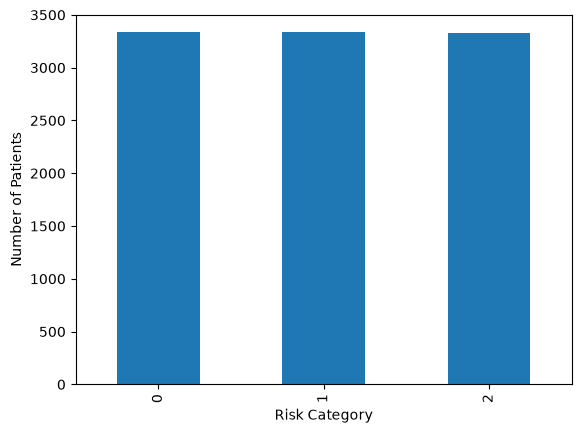

In [7]:
import matplotlib.pyplot as plt

df["Diabetes_Risk"].value_counts().plot(kind="bar")

plt.xlabel("Risk Category")
plt.ylabel("Number of Patients")
plt.show()

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


categorical = [
"Family_History_of_Diabetes",
"Physical_Activity_Level",
"Smoking_Status"
]


preprocessor = ColumnTransformer(
[
("cat",
 OneHotEncoder(handle_unknown="ignore"),
 categorical)
],
remainder="passthrough"
)

In [9]:
from sklearn.model_selection import train_test_split
X = df[features]
y = df["Diabetes_Risk"]


X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)
model = Pipeline(
[
("preprocessor",preprocessor),
("classifier",
 RandomForestClassifier(
 n_estimators=100,
 random_state=42
 ))
]
)


model.fit(
X_train,
y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','BMI','Waist_Circumference',...,'Family_History_of_Diabetes', 'Physical_Activity_Level','Smoking_Status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [11]:

rf = model.named_steps["classifier"]

importance = pd.DataFrame(
{
"Feature": model.named_steps["preprocessor"].get_feature_names_out(),
"Importance": rf.feature_importances_
}
)

importance.sort_values(
by="Importance",
ascending=False
).head(10)

,Feature,Importance
11,remainder__Fasting_Blood_Glucose,0.726841
10,remainder__Waist_Circumference,0.035559
8,remainder__Age,0.029397
12,remainder__HbA1c,0.028722
9,remainder__BMI,0.027138
16,remainder__Cholesterol_LDL,0.023333
15,remainder__Cholesterol_HDL,0.023240
17,remainder__GGT,0.022802
13,remainder__Blood_Pressure_Systolic,0.020799
14,remainder__Blood_Pressure_Diastolic,0.019748


In [12]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline


xgb_model = Pipeline(
[
    ("preprocessor", preprocessor),

    ("classifier",
     XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
     ))
]
)


xgb_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','BMI','Waist_Circumference',...,'Family_History_of_Diabetes', 'Physical_Activity_Level','Smoking_Status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [13]:
xgb_pred = xgb_model.predict(X_test)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


print(
accuracy_score(
y_test,
xgb_pred
)
)


print(
classification_report(
y_test,
xgb_pred,
zero_division=0
)
)


print(
confusion_matrix(
y_test,
xgb_pred
)
)

0.975
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       683
           1       0.96      0.97      0.96       665
           2       0.97      0.98      0.98       652

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.98      0.97      0.98      2000

[[670  13   0]
 [  5 643  17]
 [  0  15 637]]


In [15]:
prediction = model.predict(X_test)


print(
classification_report(
y_test,
prediction,
zero_division=0
)
)


              precision    recall  f1-score   support

           0       0.97      0.95      0.96       683
           1       0.91      0.93      0.92       665
           2       0.96      0.95      0.95       652

    accuracy                           0.94      2000
   macro avg       0.95      0.94      0.95      2000
weighted avg       0.95      0.94      0.95      2000



c:\Users\Krishna Rajoo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


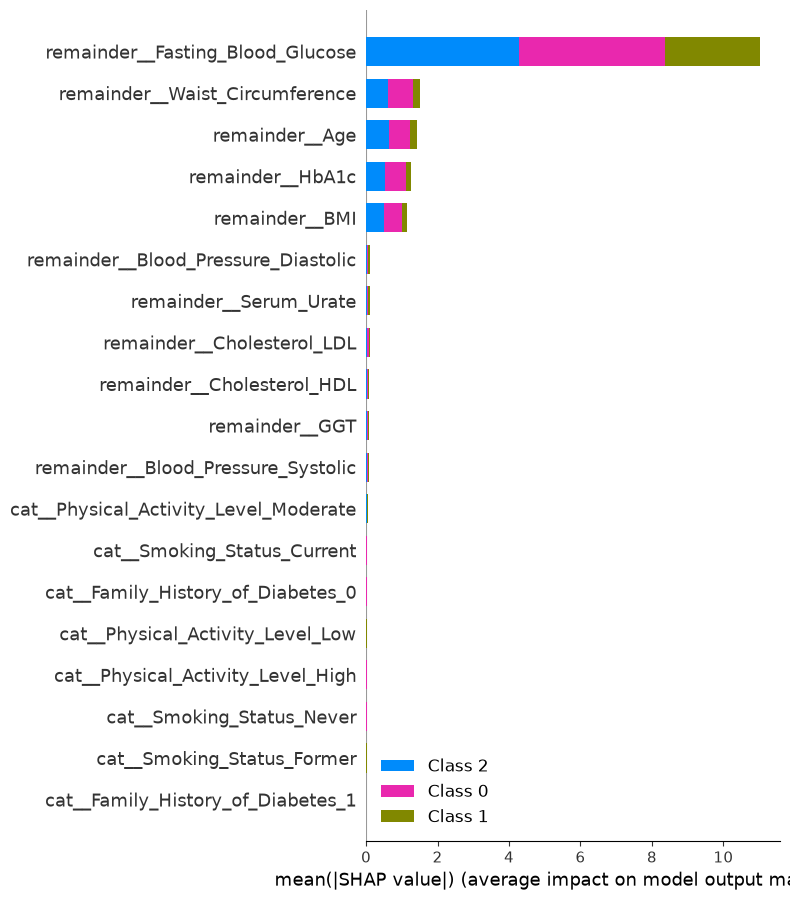

In [16]:
import shap

# Transform test data
X_test_transformed = (
    xgb_model
    .named_steps["preprocessor"]
    .transform(X_test)
)


# Get feature names
feature_names = (
    xgb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)


# Create SHAP explainer
explainer = shap.TreeExplainer(
    xgb_model.named_steps["classifier"]
)


shap_values = explainer(
    X_test_transformed
)


# SHAP summary plot with names
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

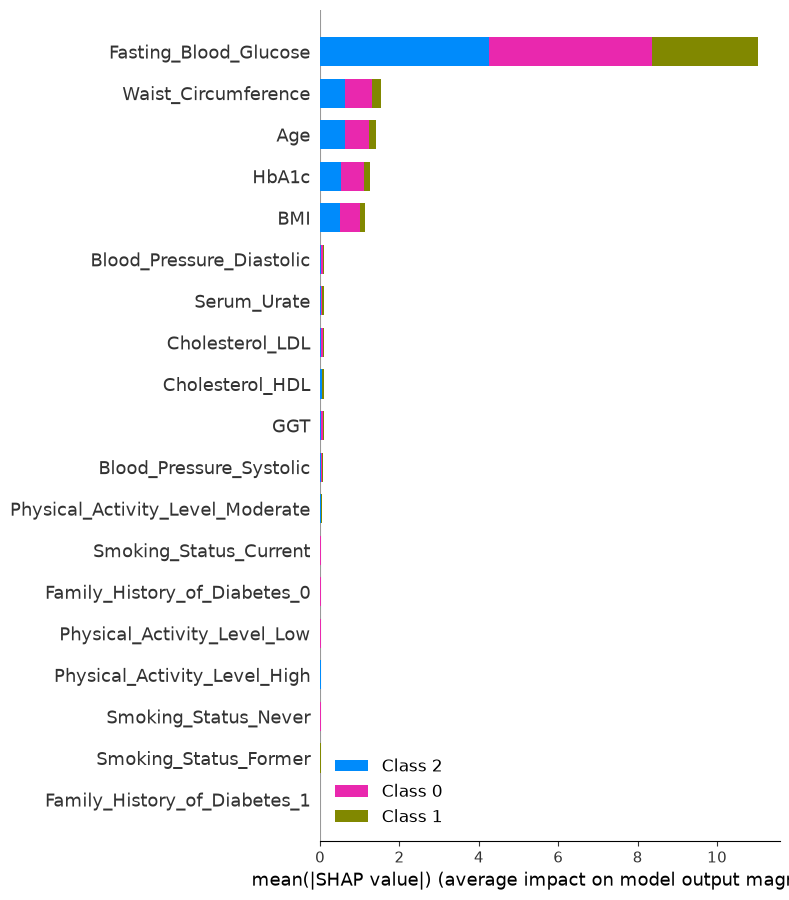

In [17]:
feature_names = [
    name.replace("remainder__", "")
        .replace("cat__", "")
    for name in feature_names
]
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [18]:
import pickle

pickle.dump(
    xgb_model,
    open("diabetes_xgb_model.pkl","wb")
)

pickle.dump(
    explainer,
    open("shap_explainer.pkl","wb")
)